# Philadelphia Vehicular Crash Reports in Youth:


### Exploring the intersection between teen drivers and proximity to Philadelphia school districts
---

Philadelphia is a dominantly urban landscape, home to thousands of families that rely on cars to get around the city. With such a large population of residents, there are an abundance of school districts in the area. At the same time, Philadelphia experiences a large volume of accidents per year. Among these accidents, teenage drivers who are less experienced at the wheel are frequently involved in crashes. This raises the important question: Is there a relationship between the location of school districts and the number of car accidents involving teenage drivers? By examining crash data for drivers ages 16–20 and comparing it with the geographic distribution of Philadelphia schools, this analysis explores whether teen driver crashes tend to occur near school zones or if they are more broadly distributed throughout the city.

### Setup:

We are going to be using python for this example:

In [2]:
import pandas as pd
import geopandas as gpd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import datetime as dt

In [3]:
crash_data = pd.read_csv('data/PDOT_crash_data_2005_2024.csv', low_memory=False)

Firstly, we are going to be sorting the data to examine drivers between the ages of 16 and 20:

In [73]:
crash_data['DRIVER_COUNT_16_20'] = crash_data[
    ['DRIVER_COUNT_16YR',
     'DRIVER_COUNT_17YR',
     'DRIVER_COUNT_18YR',
     'DRIVER_COUNT_19YR',
     'DRIVER_COUNT_20YR']
].sum(axis=1)

In [74]:
teen_crashes = crash_data[crash_data["DRIVER_COUNT_16_20"] > 0].copy()

In [75]:
age_counts = crash_data[
    [
        "DRIVER_COUNT_16YR",
        "DRIVER_COUNT_17YR",
        "DRIVER_COUNT_18YR",
        "DRIVER_COUNT_19YR",
        "DRIVER_COUNT_20YR"
    ]
].sum()

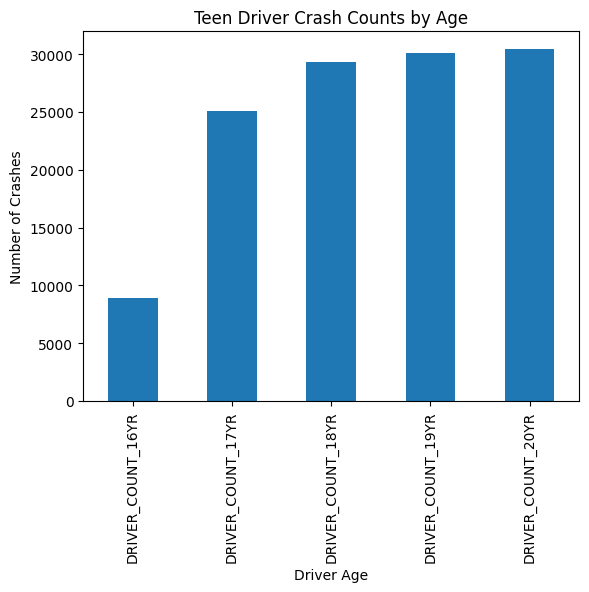

In [76]:
import matplotlib.pyplot as plt

age_counts.plot(kind="bar")

plt.title("Teen Driver Crash Counts by Age")
plt.xlabel("Driver Age")
plt.ylabel("Number of Crashes")

plt.show()

In [77]:
crash_data["DRIVER_COUNT_16_20"].sum()
print("Number of Philly Car Crashes for 16–20 year olds:", crash_data["DRIVER_COUNT_16_20"].sum())

Number of Philly Car Crashes for 16–20 year olds: 123938


On record, there have been an abundance of car crashes reported between the ages of 16 and 20. However, the number of crashes increases relatively each year, jumping significantly for car crashes from 16 to 17-year-olds.

Next, we're going to dive into the number of schools in the Philadelphia District as well as where they're geographically located.

In [78]:
import pandas as pd

schools = gpd.read_file("Schools(1).geojson")
schools.head()

,aun,school_num,location_id,school_name,school_name_label,street_address,zip_code,phone_number,grade_level,grade_org,enrollment,type,type_specific,objectid,geometry
0,226518902.0,NaN,NaN,ST MARYS INTERPAROCHIAL SCHOOL,ST MARYS INTERPAROCHIAL SCHOOL,440 LOCUST ST,19106,(215) 923-7522,ELEMENTARY/MIDDLE,K-8,NaN,3,ARCHDIOCESE,1,POINT (-75.14961 39.94605)
1,226518722.0,NaN,NaN,ST MARTHA SCHOOL,ST MARTHA SCHOOL,11321 ACADEMY RD,19154,(215) 632-0320,ELEMENTARY/MIDDLE,PREK-8,NaN,3,ARCHDIOCESE,2,POINT (-74.98505 40.08758)
2,226514052.0,NaN,NaN,MATERNITY BVM SCHOOL,MATERNITY BVM SCHOOL,9322 OLD BUSTLETON AVE,19115,(215) 673-0235,ELEMENTARY/MIDDLE,PREK-8,NaN,3,ARCHDIOCESE,3,POINT (-75.03899 40.08192)
3,226514852.0,NaN,NaN,OUR LADY OF CALVARY SCHOOL,OUR LADY OF CALVARY SCHOOL,11023 KIPLING LN,19154,(215) 637-1648,ELEMENTARY/MIDDLE,PREK-8,NaN,3,ARCHDIOCESE,4,POINT (-74.97891 40.07938)
4,226511102.0,NaN,NaN,CHRIST THE KING SCHOOL,CHRIST THE KING SCHOOL,3205 CHESTERFIELD RD,19114,(215) 632-1375,ELEMENTARY/MIDDLE,PREK-8,NaN,3,ARCHDIOCESE,5,POINT (-74.9953 40.07528)


In [79]:
schools.head()
schools.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [80]:
schools = schools.to_crs("EPSG:4326")  # ensure lat/lon CRS
schools["longitude"] = schools.geometry.x
schools["latitude"]  = schools.geometry.y

schools[["latitude","longitude"]].head()

,latitude,longitude
0,39.946051,-75.149612
1,40.087578,-74.985049
2,40.081923,-75.038992
3,40.079378,-74.978907
4,40.075282,-74.995301


In [81]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Polygons: Philly neighborhoods / districts / tracts etc.
philly_polys = gpd.read_file("philly_boundaries.geojson")   # <-- your polygon file

# Points: schools
schools_gdp = gpd.read_file("Schools(1).geojson")

In [82]:
# philly_polys = your school district polygons
# schools = your school points

print("philly CRS:", philly_polys.crs)
print("schools CRS:", schools.crs)

# If either is missing CRS:
if philly_polys.crs is None:
    philly_polys = philly_polys.set_crs("EPSG:4326")

if schools.crs is None:
    schools = schools.set_crs("EPSG:4326")

# Reproject schools to match polygons
schools = schools.to_crs(philly_polys.crs)

philly CRS: EPSG:4326
schools CRS: EPSG:4326


In [83]:
schools_4326 = schools.to_crs("EPSG:4326")
schools_clean = schools_4326[
    schools_4326.geometry.x.between(-76, -74) &
    schools_4326.geometry.y.between(39, 41)
].copy()

# put back to polygon CRS for plotting
schools_clean = schools_clean.to_crs(philly_polys.crs)

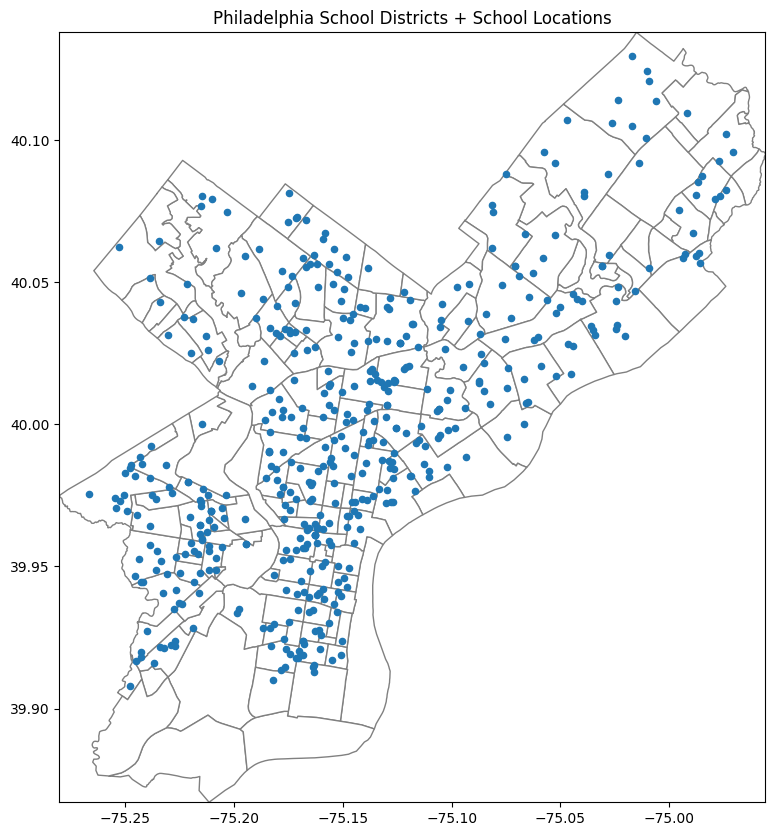

In [84]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

philly_polys.plot(ax=ax, facecolor="white", edgecolor="gray", linewidth=1)
schools_clean.plot(ax=ax, markersize=20)

minx, miny, maxx, maxy = philly_polys.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title("Philadelphia School Districts + School Locations")
plt.show()

As seen above, there are 490 schools in the Philadelphia area. But what is the correlation between teen car crashes and distance to schools?

In [85]:
print(philly_polys.crs, schools.crs)
print("philly:", philly_polys.total_bounds)
print("schools:", schools.total_bounds)

EPSG:4326 EPSG:4326
philly: [-75.28026419  39.86700576 -74.95576188  40.13799279]
schools: [-75.26649721  39.90781232 -74.97056957  40.12973865]


In [86]:
teen_crashes = crash_data[crash_data["DRIVER_COUNT_16_20"] > 0].copy()

In [87]:
teen_crashes = teen_crashes.dropna(subset=["DEC_LATITUDE", "DEC_LONGITUDE"]).copy()

In [88]:
import geopandas as gpd

crash_gdf = gpd.GeoDataFrame(
    teen_crashes,
    geometry=gpd.points_from_xy(
        teen_crashes["DEC_LONGITUDE"],
        teen_crashes["DEC_LATITUDE"]
    ),
    crs="EPSG:4326"
)

In [89]:
crash_proj = crash_gdf.to_crs(epsg=2272)
schools_proj = schools.to_crs(epsg=2272)

In [90]:
schools_buffer = schools_proj.copy()
schools_buffer["geometry"] = schools_buffer.buffer(1640)

In [91]:
crashes_near_schools = gpd.sjoin(
    crash_proj,
    schools_buffer,
    predicate="within",
    how="inner"
)

In [92]:
total_teen_crashes = len(crash_proj)
near_school_crashes = len(crashes_near_schools)

percent = (near_school_crashes / total_teen_crashes) * 100

print(f"Total teen crashes: {total_teen_crashes:,}")
print(f"Teen crashes near schools: {near_school_crashes:,}")
print(f"Percent near schools: {percent:.2f}%")

Total teen crashes: 113,550
Teen crashes near schools: 31,068
Percent near schools: 27.36%


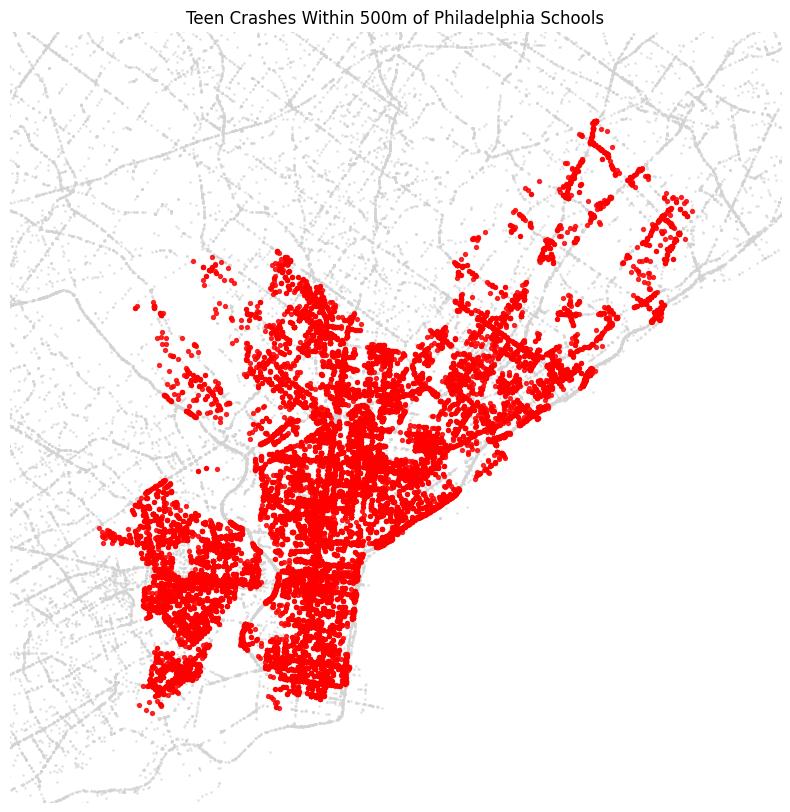

In [93]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

# plot both layers
crash_proj.plot(ax=ax, color="lightgray", markersize=1, alpha=0.5)
crashes_near_schools.plot(ax=ax, color="red", markersize=8, alpha=0.8)

# zoom to red region
minx, miny, maxx, maxy = crashes_near_schools.total_bounds
pad_x = (maxx - minx) * 0.15
pad_y = (maxy - miny) * 0.15

ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

plt.title("Teen Crashes Within 500m of Philadelphia Schools")
ax.set_axis_off()
plt.show()

In [94]:
import geopandas as gpd

districts_2272 = philly_polys.to_crs(epsg=2272)   # your Philly district polygons
philly_boundary = districts_2272.unary_union      # single shape

/tmp/ipykernel_2979610/3843307436.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  philly_boundary = districts_2272.unary_union      # single shape


In [95]:
crash_philly = crash_proj[crash_proj.within(philly_boundary)].copy()

In [96]:
near_philly = crashes_near_schools[crashes_near_schools.within(philly_boundary)].copy()

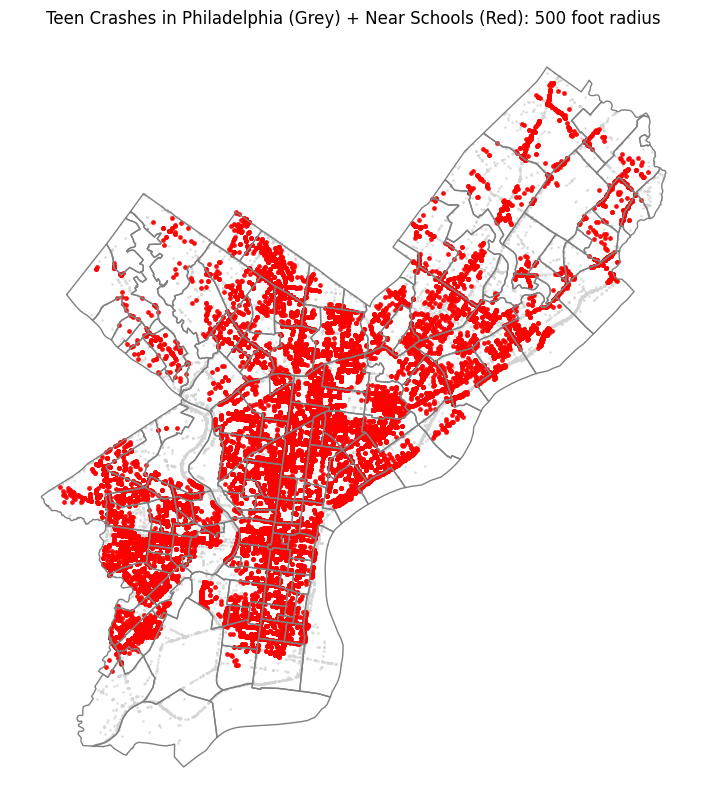

In [97]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

# Philly outline (optional but nice)
districts_2272.boundary.plot(ax=ax, color="gray", linewidth=1)

# Grey = all teen crashes inside Philly
crash_philly.plot(ax=ax, color="lightgray", markersize=1, alpha=0.6)

# Red = teen crashes near schools (inside Philly)
near_philly.plot(ax=ax, color="red", markersize=6, alpha=0.9)

ax.set_axis_off()
plt.title("Teen Crashes in Philadelphia (Grey) + Near Schools (Red): 500 foot radius")
plt.show()

In [98]:
len(crashes_near_schools)

31068

In [99]:
len(crash_proj)

113550

In [100]:
crashes_near_schools.groupby("school_name").size().sort_values(ascending=False)

school_name
STUDENT TRANSITION CENTER                      554
ROMAN CATHOLIC HIGH SCHOOL                     339
PHILADELPHIA PERFORMING ARTS CHARTER SCHOOL    303
FRIENDS SELECT SCHOOL                          292
RE-ENGAGEMENT CENTER                           284
                                              ... 
NEW OAKS ACADEMY                                 5
RED LION ELEMENTARY SCHOOL                       5
SPRINGSIDE CHESTNUT HILL ACADEMY                 5
PHILADELPHIA ACADEMY CHARTER SCHOOL (ANNEX)      4
LANKENAU HIGH SCHOOL                             3
Length: 476, dtype: int64

Ultimately, out of 113,420 crashes committed by teens from ages 16 to 20, only 2,873 occurred in a 500 meter radius of schools in the Philadelphia area, representing a relatively small share of total incidents. This suggests that while school zones may experience concentrated traffic at certain times of day, they are not the primary locations where teen driver crashes occur. Instead, teen crashes appear to be dispersed across the broader urban road network, indicating that factors such as roadway design, traffic volume, and commuting routes may have a stronger influence on crash locations than school proximity alone.